<a href="https://colab.research.google.com/github/Afrin-mte/OIBSIP/blob/main/Task_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Wine Quality Prediction**

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
sns.set_theme(style="whitegrid")
df = pd.read_csv('WineQT.csv')
df.head()
df.shape
df.info()
print("Missing Values Count: ")
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB
Missing Values Count: 
fixed acidity           0
volatile acidity        0


**Data Visualization**

/tmp/ipykernel_2310/3587161317.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=df, palette='muted')


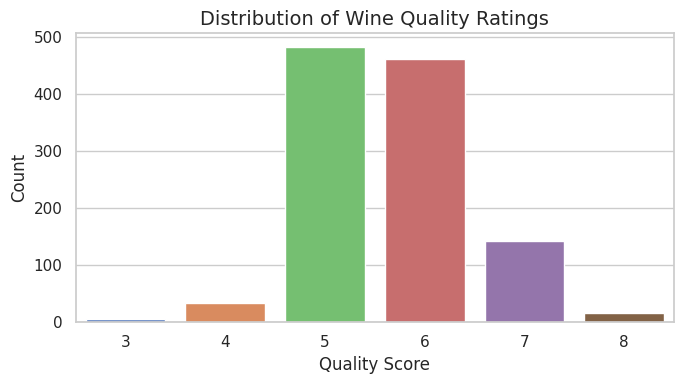

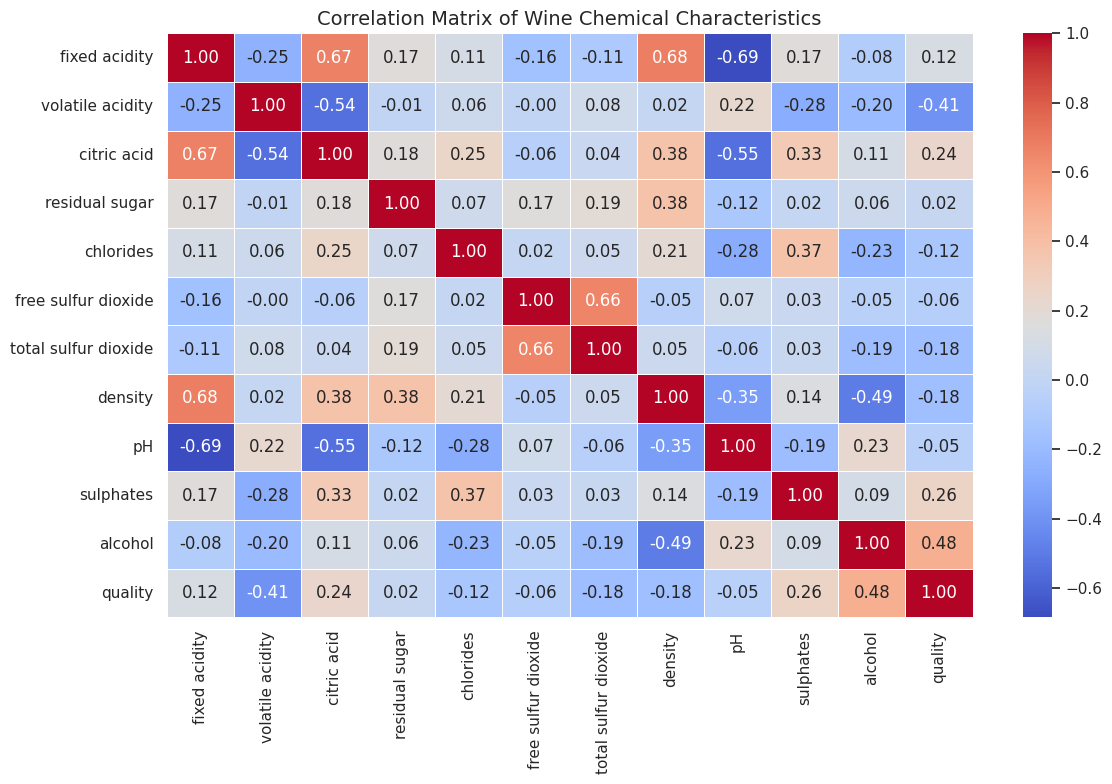

In [5]:
plt.figure(figsize=(7, 4))
sns.countplot(x='quality', data=df, palette='muted')
plt.title('Distribution of Wine Quality Ratings', fontsize=14)
plt.xlabel('Quality Score', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()
#Correlation heatmap among chemical properties (excluding the 'Id' column)
plt.figure(figsize=(12, 8))
correlation_matrix = df.drop(columns=['Id']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Wine Chemical Characteristics', fontsize=14)
plt.tight_layout()
plt.show()

**Data Preprocessing & Feature Engineering**

In [11]:

# Binarizing quality: 1 for Good Wine (Quality >= 6), 0 for Bad/Average Wine (Quality < 6)
df['quality_bin'] = (df['quality'] >= 6).astype(int)
print("Binary Distribution of Wine Quality")
print(df['quality_bin'].value_counts().rename(index={1: 'Good (1)', 0: 'Bad/Average (0)'}))

Binary Distribution of Wine Quality
quality_bin
Good (1)           621
Bad/Average (0)    522
Name: count, dtype: int64


**Train-Test Split and Feature Scaling**

In [12]:
X = df.drop(columns=['quality', 'quality_bin'])
y = df['quality_bin']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Training set size: {X_train_scaled.shape[0]} samples")
print(f"Testing set size: {X_test_scaled.shape[0]} samples")

Training set size: 914 samples
Testing set size: 229 samples


**Model 1 — Random Forest Classifier**

In [13]:
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
rf_acc = accuracy_score(y_test, y_pred_rf)
print("Random Forest Performance")
print(f"Accuracy: {rf_acc:.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Performance
Accuracy: 0.7729

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.75      0.75       102
           1       0.80      0.79      0.79       127

    accuracy                           0.77       229
   macro avg       0.77      0.77      0.77       229
weighted avg       0.77      0.77      0.77       229



**Model 2 — Stochastic Gradient Descent (SGD) Classifier**

In [14]:
sgd_model = SGDClassifier(random_state=42, max_iter=1000, tol=1e-3)
sgd_model.fit(X_train_scaled, y_train)
y_pred_sgd = sgd_model.predict(X_test_scaled)
sgd_acc = accuracy_score(y_test, y_pred_sgd)
print("SGD Classifier Performance: ")
print(f"Accuracy: {sgd_acc:.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred_sgd))

SGD Classifier Performance: 
Accuracy: 0.7162

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.69      0.68       102
           1       0.75      0.74      0.74       127

    accuracy                           0.72       229
   macro avg       0.71      0.71      0.71       229
weighted avg       0.72      0.72      0.72       229



**Model 3 — Support Vector Classifier (SVC)**

In [15]:
svc_model = SVC(random_state=42, kernel='rbf')
svc_model.fit(X_train_scaled, y_train)
y_pred_svc = svc_model.predict(X_test_scaled)
svc_acc = accuracy_score(y_test, y_pred_svc)
print("Support Vector Classifier Performance:")
print(f"Accuracy: {svc_acc:.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred_svc))

Support Vector Classifier Performance:
Accuracy: 0.7642

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.72      0.73       102
           1       0.78      0.80      0.79       127

    accuracy                           0.76       229
   macro avg       0.76      0.76      0.76       229
weighted avg       0.76      0.76      0.76       229



**Model Performance Comparison Visualization**

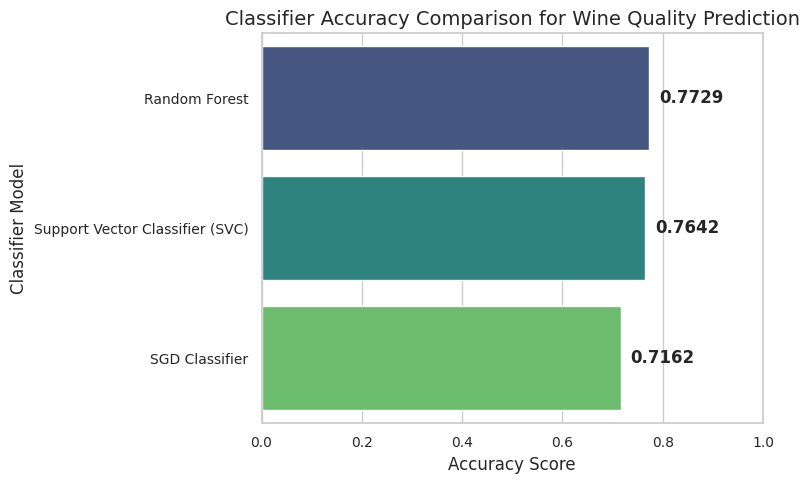

In [16]:
model_scores = {
    'Random Forest': rf_acc,
    'Support Vector Classifier (SVC)': svc_acc,
    'SGD Classifier': sgd_acc
}
# Sorting the dictionary values in descending order for the visualization layout
sorted_scores = dict(sorted(model_scores.items(), key=lambda item: item[1], reverse=True))

plt.figure(figsize=(8, 5))
sns.barplot(x=list(sorted_scores.values()), y=list(sorted_scores.keys()), palette='viridis', hue=list(sorted_scores.keys()), legend=False)
plt.title('Classifier Accuracy Comparison for Wine Quality Prediction', fontsize=14)
plt.xlabel('Accuracy Score', fontsize=12)
plt.ylabel('Classifier Model', fontsize=12)
plt.xlim(0.0, 1.0)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
for index, value in enumerate(sorted_scores.values()):
    plt.text(value + 0.02, index, f"{value:.4f}", va='center', fontweight='bold')

plt.tight_layout()
plt.show()